# BZ running-experiment TPOT vs YZ TPOT

Compare **time-per-output-token (TPOT)** for the live BZ run against the YZ prod "us" runs.

| Group | Exp | Path | Source of TPOT | Notes |
|---|---|---|---|---|
| BZ (live) | **111** | `/data/experiments/111` | `router_logs.json` `tpot_avg_s` | Claude/CodeFlow, 96 users (still running) |
| YZ (us) | **96** | `/data/experiments/yz/96` | `logs.json` `tpot_avg_s` | prod-collector, router `10.50.156.65` |
| YZ (us) | **103** | `/data/experiments/yz/103` | `logs.json` `tpot_avg_s` | prod-collector, later run (prefix-drop era) |

- Everything is converted to **ms/token** (`tpot_avg_s * 1000`).
- Per-request TPOT is timestamped by `t0_wall` (send) and smoothed with a rolling window.
- YZ-103 has a few multi-second stalls; `TPOT_CLIP_MS` drops obvious outliers for the plots (median/p95 are robust either way).

In [ ]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/data/experiments")

# Experiments to compare. group drives colour/linestyle; path is explicit so
# YZ (under yz/) and BZ (top level) both resolve.
EXPS = {
    111: {"group": "BZ", "label": "BZ-111 (claude/codeflow, live)", "path": ROOT / "111",     "color": "#1f77b4"},
    96:  {"group": "YZ", "label": "YZ-96 (prod us)",                "path": ROOT / "yz" / "96",  "color": "#d62728"},
    103: {"group": "YZ", "label": "YZ-103 (prod us)",               "path": ROOT / "yz" / "103", "color": "#ff7f0e"},
}

ROLL = "5min"       # rolling window for the smoothed series
TPOT_CLIP_MS = 2000  # drop per-request TPOT above this (obvious stalls) for plots; None = keep all

for eid, m in EXPS.items():
    print(eid, m["group"], "exists", m["path"].exists(),
          "| logs", (m["path"] / "logs.json").is_file(),
          "| router_logs", (m["path"] / "router_logs.json").is_file())

111 BZ exists True | logs True | router_logs True
96 YZ exists True | logs True | router_logs False
103 YZ exists True | logs True | router_logs True


## 1. Load per-request TPOT over time

For each experiment, prefer `logs.json` when it carries `tpot_avg_s` (YZ prod-collector runs),
otherwise fall back to `router_logs.json` (the Claude BZ run has no client-side TPOT). TPOT is
converted to ms/token and timestamped by `t0_wall`.

In [ ]:
def _read_ndjson(path: Path):
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    # tolerate a half-written last line on the live run
                    pass
    return rows


def load_tpot(exp_id: int, clip_ms=TPOT_CLIP_MS) -> pd.DataFrame:
    meta = EXPS[exp_id]
    d = meta["path"]
    logs, router = d / "logs.json", d / "router_logs.json"

    src_path, source = None, None
    if logs.is_file():
        probe = _read_ndjson(logs)
        if any(r.get("tpot_avg_s") is not None for r in probe):
            src_path, source = logs, "logs.json"
    if src_path is None and router.is_file():
        probe = _read_ndjson(router)
        src_path, source = router, "router_logs.json"
    if src_path is None:
        raise FileNotFoundError(f"no tpot source for exp {exp_id} in {d}")

    rows = []
    for r in probe:
        tpot = r.get("tpot_avg_s")
        ts = r.get("t0_wall") or r.get("t1_wall") or r.get("actual_send_ts_wall")
        if tpot is None or ts is None:
            continue
        rows.append({
            "exp": exp_id,
            "group": meta["group"],
            "ts": pd.to_datetime(ts, unit="s", utc=True),
            "tpot_ms": float(tpot) * 1000.0,
            "completion_tokens": r.get("completion_tokens"),
            "source": source,
        })
    df = pd.DataFrame(rows).sort_values("ts").reset_index(drop=True)
    df["tpot_ms_plot"] = df["tpot_ms"]
    if clip_ms is not None:
        df.loc[df["tpot_ms"] > clip_ms, "tpot_ms_plot"] = np.nan
    n_clip = int((df["tpot_ms"] > clip_ms).sum()) if clip_ms is not None else 0
    print(f"exp {exp_id:>4} [{meta['group']}]: {len(df):>6} reqs from {source:<16}"
          f" | p50={df['tpot_ms'].median():6.1f} ms | p95={df['tpot_ms'].quantile(0.95):6.1f} ms"
          f" | max={df['tpot_ms'].max():8.1f} ms | clipped>{clip_ms}ms: {n_clip}"
          f" | {df['ts'].min()} -> {df['ts'].max()}")
    return df


tpot = {eid: load_tpot(eid) for eid in EXPS}
tpot_all = pd.concat(tpot.values(), ignore_index=True)
tpot_all.head()

exp  111 [BZ]:   8639 reqs from router_logs.json | p50= 148.4 ms | p95= 178.5 ms | max=   214.4 ms | clipped>2000ms: 0 | 2026-07-15 15:26:13.741308212+00:00 -> 2026-07-16 03:29:39.827640057+00:00


exp   96 [YZ]:  13982 reqs from logs.json        | p50=  91.0 ms | p95= 199.3 ms | max=  1136.8 ms | clipped>2000ms: 0 | 2026-07-11 06:56:04.394142866+00:00 -> 2026-07-14 02:19:07.455720901+00:00


exp  103 [YZ]:    969 reqs from logs.json        | p50= 100.0 ms | p95= 271.7 ms | max=205597.1 ms | clipped>2000ms: 9 | 2026-07-14 17:08:57.528876066+00:00 -> 2026-07-14 20:36:13.338953972+00:00


,exp,group,ts,tpot_ms,completion_tokens,source,tpot_ms_plot
0,111,BZ,2026-07-15 15:26:13.741308212+00:00,33.22,869,router_logs.json,33.22
1,111,BZ,2026-07-15 15:26:17.143868685+00:00,107.08,8616,router_logs.json,107.08
2,111,BZ,2026-07-15 15:26:17.844934940+00:00,108.73,4711,router_logs.json,108.73
3,111,BZ,2026-07-15 15:26:17.904069424+00:00,67.29,1218,router_logs.json,67.29
4,111,BZ,2026-07-15 15:26:18.844129086+00:00,57.67,1200,router_logs.json,57.67


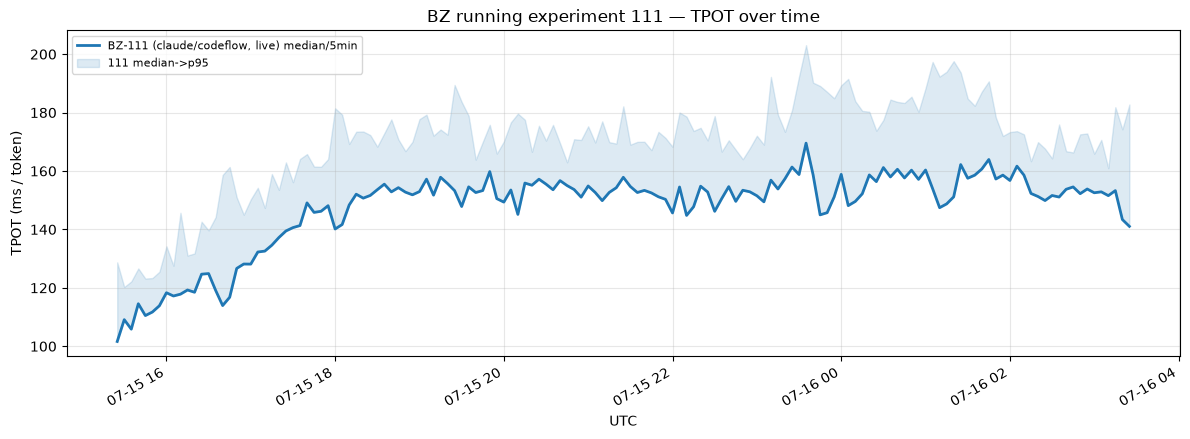

In [ ]:
def rolled(df: pd.DataFrame, freq: str = ROLL) -> pd.DataFrame:
    if df.empty:
        return df
    s = df.set_index("ts")["tpot_ms_plot"]
    out = pd.DataFrame({
        "tpot_ms_med": s.resample(freq).median(),
        "tpot_ms_p95": s.resample(freq).quantile(0.95),
        "n": s.resample(freq).count(),
    }).dropna(subset=["tpot_ms_med"]).reset_index()
    return out


# BZ live run — TPOT over time (this is the "running experiment" view).
fig, ax = plt.subplots(figsize=(12, 4.5))
for eid, meta in EXPS.items():
    if meta["group"] != "BZ":
        continue
    r = rolled(tpot[eid])
    ax.plot(r["ts"], r["tpot_ms_med"], color=meta["color"], lw=2,
            label=f'{meta["label"]} median/{ROLL}')
    ax.fill_between(r["ts"], r["tpot_ms_med"], r["tpot_ms_p95"],
                    color=meta["color"], alpha=0.15, label=f'{eid} median->p95')
ax.set_ylabel("TPOT (ms / token)")
ax.set_xlabel("UTC")
ax.set_title("BZ running experiment 111 — TPOT over time")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 2. BZ vs YZ — side by side

Absolute clocks differ (BZ live now vs YZ prod earlier), so two views:
1. **Aligned from t=0** — each series shifted to hours-since-start (level + ramp comparison).
2. **Distribution** — per-request TPOT ECDF / summary (level comparison independent of time).

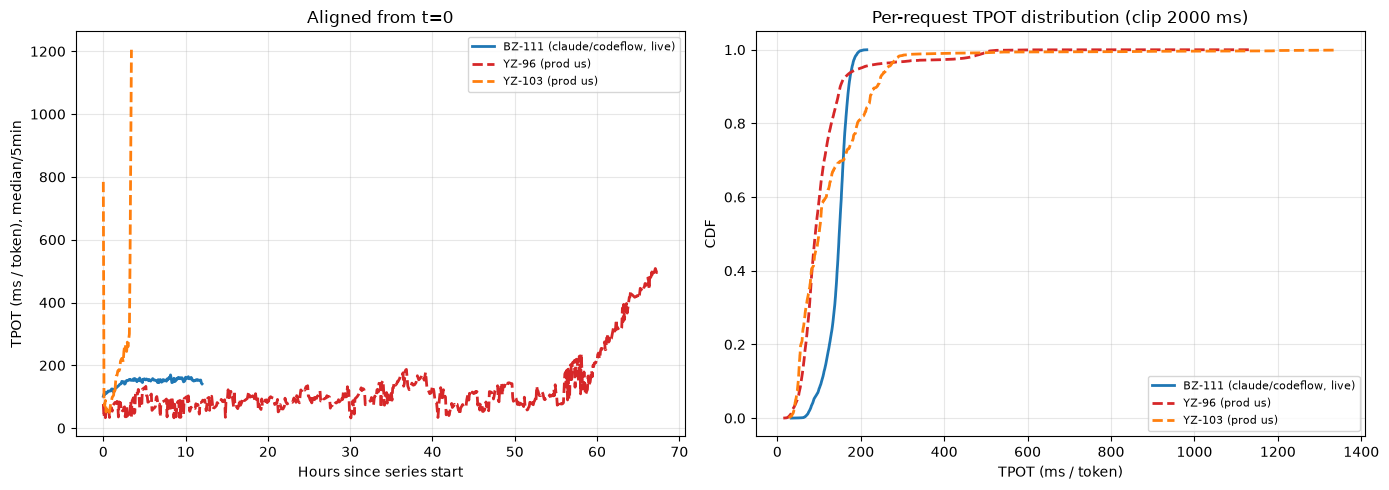

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- (1) aligned from t=0 (hours) ---
ax = axes[0]
for eid, meta in EXPS.items():
    r = rolled(tpot[eid])
    if r.empty:
        continue
    hours = (r["ts"] - r["ts"].iloc[0]).dt.total_seconds() / 3600.0
    ls = "-" if meta["group"] == "BZ" else "--"
    ax.plot(hours, r["tpot_ms_med"], color=meta["color"], lw=2, ls=ls, label=meta["label"])
ax.set_xlabel("Hours since series start")
ax.set_ylabel(f"TPOT (ms / token), median/{ROLL}")
ax.set_title("Aligned from t=0")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

# --- (2) ECDF of per-request TPOT ---
ax = axes[1]
for eid, meta in EXPS.items():
    v = tpot[eid]["tpot_ms_plot"].dropna().sort_values()
    if v.empty:
        continue
    y = np.linspace(0, 1, len(v), endpoint=False)
    ls = "-" if meta["group"] == "BZ" else "--"
    ax.plot(v, y, color=meta["color"], lw=2, ls=ls, label=meta["label"])
ax.set_xlabel("TPOT (ms / token)")
ax.set_ylabel("CDF")
ax.set_title(f"Per-request TPOT distribution (clip {TPOT_CLIP_MS} ms)")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Level comparison table (raw per-request, no clip)
rows = []
for eid, meta in EXPS.items():
    df = tpot[eid]
    rows.append({
        "series": meta["label"],
        "group": meta["group"],
        "n": len(df),
        "p50_ms": round(df["tpot_ms"].median(), 1),
        "p90_ms": round(df["tpot_ms"].quantile(0.90), 1),
        "p95_ms": round(df["tpot_ms"].quantile(0.95), 1),
        "p99_ms": round(df["tpot_ms"].quantile(0.99), 1),
        "max_ms": round(df["tpot_ms"].max(), 1),
        "span_min": round((df["ts"].max() - df["ts"].min()).total_seconds() / 60, 1),
    })
summary = pd.DataFrame(rows).sort_values(["group", "p50_ms"]).reset_index(drop=True)
summary

,series,group,n,p50_ms,p90_ms,p95_ms,p99_ms,max_ms,span_min
0,"BZ-111 (claude/codeflow, live)",BZ,8639,148.4,171.2,178.5,191.6,214.4,723.4
1,YZ-96 (prod us),YZ,13982,91.0,150.8,199.3,493.1,1136.8,4043.1
2,YZ-103 (prod us),YZ,969,100.0,243.0,271.7,1249.0,205597.1,207.3


## 3. Their YZ (bare vLLM `142`) — derived TPOT

The YZ "them" runs are external scrapes (no per-request `logs.json`), so TPOT is **derived from vLLM
`/metrics`** over a rolling window — same method as `prefix-kv-drop-root-cause.ipynb`:

\[ \mathrm{TPOT} = \frac{\overline{\texttt{decode\_time\_seconds\_avg}}\;\cdot\;\sum \texttt{request\_success\_per\_sec}}{\sum \texttt{gen\_tokens\_per\_sec}} \quad (\text{s/token}) \]

Near-idle ticks (very low completion rate) are blanked because the ratio is meaningless there.
These are **per-tick derived** values, not per-request, so they go on the time-series comparison and the
summary table (flagged `prom-derived`), not the per-request ECDF.

| Them exp | Pairs with (us) |
|---|---|
| **95** | 96 |
| **102** | 103 |

In [6]:
import re

# YZ "them" (bare vLLM 142) external scrapes. path + colour + which us exp it pairs with.
THEM_EXPS = {
    95:  {"label": "YZ-95 them (142)",  "path": ROOT / "yz" / "95",  "color": "#9467bd", "pairs": 96},
    102: {"label": "YZ-102 them (142)", "path": ROOT / "yz" / "102", "color": "#8c564b", "pairs": 103},
}


def load_them_tpot(exp_id: int, freq: str = ROLL) -> pd.DataFrame:
    """Derive TPOT (ms/token) over time from a them-142 external scrape.

    TPOT = mean(decode_time_seconds_avg) * sum(request_success_per_sec)
                                          / sum(gen_tokens_per_sec)
    computed on rolling windows; near-idle ticks blanked.
    """
    meta = THEM_EXPS[exp_id]
    rows = []
    with (meta["path"] / "metrics.jsonl").open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                o = json.loads(line)
            except json.JSONDecodeError:
                continue
            ts = o.get("ts")
            for s in o.get("samples") or []:
                inst = str(s.get("instance", ""))
                # engine rows only (…:port:rank) — skip the rank-less aggregate row
                if not re.search(r":\d+:\d+$", inst):
                    continue
                rows.append({
                    "ts": ts,
                    "decode": s.get("decode_time_seconds_avg"),
                    "req": s.get("request_success_per_sec"),
                    "gen": s.get("gen_tokens_per_sec"),
                })
    df = pd.DataFrame(rows)
    df["ts"] = pd.to_datetime(df["ts"], unit="s", utc=True, errors="coerce")
    df = df.dropna(subset=["ts"]).set_index("ts").sort_index()

    g = df.groupby(level=0)
    decode = g["decode"].mean()
    req = g["req"].sum()
    gen = g["gen"].sum()

    dec_r = decode.rolling(freq).mean()
    req_r = req.rolling(freq).sum()
    gen_r = gen.rolling(freq).sum()
    tpot_s = (dec_r * req_r / gen_r).replace([np.inf, -np.inf], np.nan)
    tpot_s[req_r < req_r.quantile(0.5) * 0.2] = np.nan  # blank near-idle

    out = pd.DataFrame({"ts": tpot_s.index, "tpot_ms": tpot_s.values * 1000.0}).dropna()
    print(f"exp {exp_id:>4} [YZ-them]: {len(out):>5} ticks (prom-derived)"
          f" | p50={out['tpot_ms'].median():6.1f} ms | p95={out['tpot_ms'].quantile(0.95):6.1f} ms"
          f" | {out['ts'].min()} -> {out['ts'].max()}")
    return out


them = {eid: load_them_tpot(eid) for eid in THEM_EXPS}

exp   95 [YZ-them]:  6307 ticks (prom-derived) | p50=  27.4 ms | p95= 101.9 ms | 2026-07-11 20:27:15.921130+00:00 -> 2026-07-14 02:20:27.781857+00:00


exp  102 [YZ-them]:  1111 ticks (prom-derived) | p50=  30.5 ms | p95= 143.2 ms | 2026-07-14 17:15:20.557685+00:00 -> 2026-07-15 03:31:42.482363+00:00


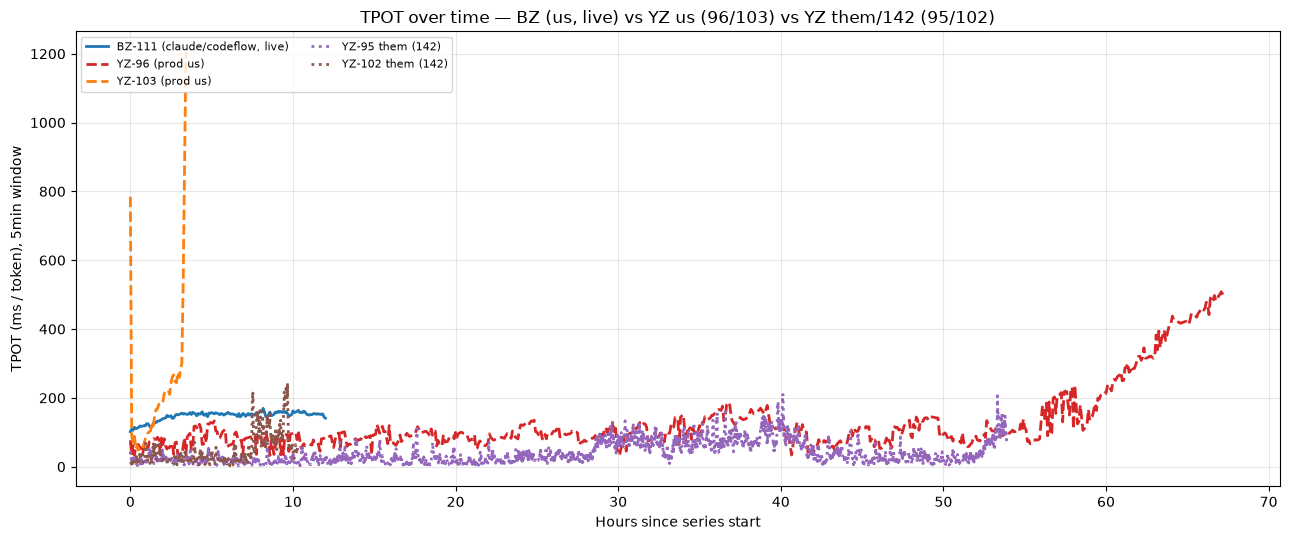

In [7]:
# Full comparison: BZ live (us) + YZ us (96/103) + YZ them (95/102), aligned from t=0.
fig, ax = plt.subplots(figsize=(13, 5.5))

# BZ + YZ-us: rolling median of per-request TPOT
for eid, meta in EXPS.items():
    r = rolled(tpot[eid])
    if r.empty:
        continue
    hours = (r["ts"] - r["ts"].iloc[0]).dt.total_seconds() / 3600.0
    ls = "-" if meta["group"] == "BZ" else "--"
    ax.plot(hours, r["tpot_ms_med"], color=meta["color"], lw=2, ls=ls, label=meta["label"])

# YZ-them: prom-derived TPOT
for eid, meta in THEM_EXPS.items():
    d = them[eid]
    if d.empty:
        continue
    hours = (d["ts"] - d["ts"].iloc[0]).dt.total_seconds() / 3600.0
    ax.plot(hours, d["tpot_ms"], color=meta["color"], lw=2, ls=":", label=meta["label"])

ax.set_xlabel("Hours since series start")
ax.set_ylabel(f"TPOT (ms / token), {ROLL} window")
ax.set_title("TPOT over time — BZ (us, live) vs YZ us (96/103) vs YZ them/142 (95/102)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [8]:
# Combined summary: per-request (BZ/YZ-us) + prom-derived (YZ-them).
rows = []
for eid, meta in EXPS.items():
    df = tpot[eid]
    rows.append({
        "series": meta["label"], "group": meta["group"], "kind": "per-request",
        "n": len(df),
        "p50_ms": round(df["tpot_ms"].median(), 1),
        "p90_ms": round(df["tpot_ms"].quantile(0.90), 1),
        "p95_ms": round(df["tpot_ms"].quantile(0.95), 1),
        "p99_ms": round(df["tpot_ms"].quantile(0.99), 1),
        "max_ms": round(df["tpot_ms"].max(), 1),
        "span_min": round((df["ts"].max() - df["ts"].min()).total_seconds() / 60, 1),
    })
for eid, meta in THEM_EXPS.items():
    d = them[eid]
    rows.append({
        "series": meta["label"], "group": "YZ-them", "kind": "prom-derived",
        "n": len(d),
        "p50_ms": round(d["tpot_ms"].median(), 1),
        "p90_ms": round(d["tpot_ms"].quantile(0.90), 1),
        "p95_ms": round(d["tpot_ms"].quantile(0.95), 1),
        "p99_ms": round(d["tpot_ms"].quantile(0.99), 1),
        "max_ms": round(d["tpot_ms"].max(), 1),
        "span_min": round((d["ts"].max() - d["ts"].min()).total_seconds() / 60, 1),
    })
summary_all = pd.DataFrame(rows).sort_values(["group", "p50_ms"]).reset_index(drop=True)
summary_all

,series,group,kind,n,p50_ms,p90_ms,p95_ms,p99_ms,max_ms,span_min
0,"BZ-111 (claude/codeflow, live)",BZ,per-request,8639,148.4,171.2,178.5,191.6,214.4,723.4
1,YZ-96 (prod us),YZ,per-request,13982,91.0,150.8,199.3,493.1,1136.8,4043.1
2,YZ-103 (prod us),YZ,per-request,969,100.0,243.0,271.7,1249.0,205597.1,207.3
3,YZ-95 them (142),YZ-them,prom-derived,6307,27.4,84.8,101.9,137.1,209.7,3233.2
4,YZ-102 them (142),YZ-them,prom-derived,1111,30.5,115.4,143.2,210.7,244.7,616.4
